<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Sector_Stages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install scipy==1.16.2

  Using cached ta-0.11.0.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=315cd6fef8a7b42103a51f269684832c9c5415591e6914d7fe2524ea8d08a8d2
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import ta
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries Installed!")

0.2.66
Libraries Installed!


# Establish Sector Correlation

In [ ]:
sector_tickers = {
    "Tech": "XLK",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Consumer_Discretionary": "XLY",
    "Consumer_Staples": "XLP",
    "Healthcare": "XLV",
    "Communications": "XLC",
    "Materials": "XLB",
    "Real_Estate": "XLRE",
    "Utilities": "XLU"
}

data = yf.download(list(sector_tickers.values()), period="1mo", interval="1d", auto_adjust=True)["Close"]

# Drop any days with missing data
data = data.dropna()

# Compute returns
returns = data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

# Compute average correlation across sectors
corr_values = corr_matrix.values
avg_corr = (np.sum(corr_values) - np.sum(np.diag(corr_values))) / (corr_values.size - len(corr_matrix))
avg_corr

# Interpret whether leadership is REAL
if avg_corr < 0.40:
    leadership = "STRONG leadership – low correlations → Great environment for LONGS"
elif avg_corr < 0.70:
    leadership = "Mixed leadership – correlations moderate → Selective longs only"
else:
    leadership = "Macro-driven market – HIGH correlations → Low follow-through, avoid aggressive longs"


# 7. Print results
corr_matrix



[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,
XLB,1.000000,0.384974,0.368096,0.831063,0.555080,-0.048811,0.707974,0.716859,0.391506,0.763273,0.629735
XLC,0.384974,1.000000,-0.042267,0.353585,0.539644,0.435608,0.184808,0.499202,0.356142,0.483368,0.736524
XLE,0.368096,-0.042267,1.000000,0.342278,-0.014235,-0.114001,0.340409,0.341347,-0.018052,0.118349,-0.019863
XLF,0.831063,0.353585,0.342278,1.000000,0.760923,0.059033,0.538806,0.783179,0.425974,0.753657,0.525070
XLI,0.555080,0.539644,-0.014235,0.760923,1.000000,0.453591,0.167116,0.525150,0.409066,0.656360,0.584362
XLK,-0.048811,0.435608,-0.114001,0.059033,0.453591,1.000000,-0.480972,-0.132897,0.154043,-0.057409,0.208398
XLP,0.707974,0.184808,0.340409,0.538806,0.167116,-0.480972,1.000000,0.651753,0.221649,0.524540,0.399561
XLRE,0.716859,0.499202,0.341347,0.783179,0.525150,-0.132897,0.651753,1.000000,0.523440,0.772397,0.489261
XLU,0.391506,0.356142,-0.018052,0.425974,0.409066,0.154043,0.221649,0.523440,1.000000,0.362005,0.495908


In [ ]:
print("\nAverage Correlation:", round(avg_corr, 3))


Average Correlation: 0.387


In [ ]:
print("\nLeadership Assessment:", leadership)


Leadership Assessment: STRONG leadership – low correlations → Great environment for LONGS


In [ ]:
returns.tail()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2025-12-15,-0.000665,0.000172,-0.007031,0.000728,0.001595,-0.009674,0.002770,0.003926,0.009106,0.013242,0.008534
2025-12-16,-0.002660,0.000686,-0.030538,-0.006365,-0.005924,0.001827,-0.004520,-0.008800,-0.004165,-0.013004,0.001643
2025-12-17,0.004222,-0.007201,0.022141,-0.000183,-0.016212,-0.022236,0.004667,0.004439,-0.006506,-0.001817,-0.011564
2025-12-18,-0.000443,0.005699,-0.014515,-0.001647,0.006513,0.015424,-0.005775,-0.006138,0.009822,0.000780,0.015101
2025-12-19,0.004428,0.000429,0.000000,0.005501,0.008607,0.021619,-0.005177,-0.003705,-0.012737,0.006692,-0.004005


## Determine Bull or Bear Regime

In [ ]:
# 1. Fetch Weekly Price Data
# ---------------------
def get_weekly(ticker, period="2y"):
    data = yf.download(ticker, period=period, interval="1wk", auto_adjust=True)
    data.dropna(inplace=True)
    return data

spy = get_weekly("SPY")
tlt = get_weekly("TLT")
vix = get_weekly("^VIX")

# ---------------------
# 2. Compute Key Indicators
# ---------------------

# 40-week SMA (≈ 200-day SMA)
spy["SMA30"] = spy["Close"].rolling(30).mean()

# Slope of SMA = current SMA - SMA 3 weeks ago
spy["SMA30_slope"] = spy["SMA30"] - spy["SMA30"].shift(3)

# VIX rising or falling trend
vix["VIX_trend_4W"] = vix["Close"] - vix["Close"].shift(4)

# TLT trend vs 30-week SMA
tlt["SMA30"] = tlt["Close"].rolling(30).mean()
tlt["SMA30_slope"] = tlt["SMA30"] - tlt["SMA30"].shift(3)

# ---------------------
# 3. % of S&P500 stocks above 200-day SMA
# ---------------------
pct_above_200 = 62
print(f"\n% of Stocks Above 200-day SMA: {pct_above_200:.1f}%")
pct_above_50 = 58
print(f"\n% of Stocks Above 50-day SMA: {pct_above_50:.1f}%")
stage2_pct = 51
print(f"\n% of Stocks in Stage 2: {stage2_pct:.1f}%")

# ---------------------
# 4. Define Regime Logic
# ---------------------
def determine_regime():

    latest = spy.iloc[-1]
    latest_vix = vix.iloc[-1]
    tlt_latest = tlt.iloc[-1]

    bullish_conditions = [
        latest["Close"].iloc[0] > latest["SMA30"].iloc[0],   # Price > 30-week SMA
        latest["SMA30_slope"].iloc[0] > 0,                   # SMA trending up
        avg_corr    < 0.5   ,                                # Leading sectors outperform strongly
        pct_above_200 > 50,                                  # Breadth positive
        pct_above_50 > 55,                                   # Short-term breadth
        stage2_pct > 55,                                     # Stage 2 leadership
        latest_vix["Close"].iloc[0] < 20 ,                   # Low volatility
        tlt_latest["Close"].iloc[0] > tlt_latest["SMA30"].iloc[0],          # TLT stable/risk-on
        tlt_latest["SMA30_slope"].iloc[0] >= 0                      # TLT not collapsing
    ]

    bearish_conditions = [
        latest["Close"].iloc[0] < latest["SMA30"].iloc[0],         # Price below 30-week SMA
        latest["SMA30_slope"].iloc[0] < 0,                         # Downtrend
        avg_corr   > 0.5   ,                                       # Leading sectors outperform strongly
        pct_above_200 < 45,
        pct_above_50 < 40,
        stage2_pct < 40,
        latest_vix["Close"].iloc[0] > 22  ,                        # Rising volatility
        tlt_latest["Close"] .iloc[0]< tlt_latest["SMA30"].iloc[0],         # Safety bid
        tlt_latest["SMA30_slope"].iloc[0] < 0
    ]

    if sum(bullish_conditions) >= 6:
        return "BULL REGIME"

    if sum(bearish_conditions) >= 6:
        return "BEAR REGIME"

    return "NEUTRAL / TRANSITION"

# ---------------------
# 5. Output regime
# ---------------------
print("Market Regime:", determine_regime())



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


% of Stocks Above 200-day SMA: 62.0%

% of Stocks Above 50-day SMA: 58.0%

% of Stocks in Stage 2: 51.0%
Market Regime: BULL REGIME


## Search for sector to  invest in

In [ ]:

# ETF universe
etfs = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC"]

# Benchmark
benchmark = yf.download("SPY", period="3y", interval="1wk", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# Classify Sector Stages

In [ ]:

def weinstein_stage(df, sma_window1=10, sma_window=30,smaSlope_window=5):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=sma_window1).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]
    # (latest_price > latest_sma) and (slope > 0)
    # (latest_price > latest_sma) and (slope > 0) and (slope_short > 0) and (latest_price > latest_10sma) and (latest_10sma > latest_sma)
    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) :
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif  np.abs(slope) <= 0.001:
        stage = "Stage 1 (Basing)"
    else:
        stage = "Stage 3 (Topping)"

    return stage, slope, latest_price, latest_sma, latest_10sma,slope_short


In [ ]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10, sma_short = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10,
            "10W_SMA_Slope": sma_short
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
advancing_sectors = stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
declining_sectors = stages_df[stages_df["Stage"] .isin(["Stage 4 (Declining)","Stage 3 (Topping)","Stage 1 (Basing)"]) ]

# Advancing sectors
advancing_sectors.reset_index(drop=True, inplace=True)

advancing_sectors

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,XLK,Stage 2 (Advancing),1.091432,144.600006,134.674188,144.239001,0.445349
1,XLV,Stage 2 (Advancing),0.748273,154.940002,140.310922,150.603999,1.504805
2,XLC,Stage 2 (Advancing),0.595339,116.519997,111.032174,114.623000,-0.011779
3,XLI,Stage 2 (Advancing),0.574976,155.860001,150.620258,153.754001,0.291934
4,XLY,Stage 2 (Advancing),0.544308,121.849998,114.462631,118.264000,0.160131
5,XLE,Stage 2 (Advancing),0.146702,44.130001,43.663281,44.736499,0.098265
6,XLF,Stage 2 (Advancing),0.138764,54.840000,52.578533,53.136000,0.075562
7,XLB,Stage 2 (Advancing),0.079986,45.369999,44.352795,44.006000,0.031884


In [ ]:
## Sectors to Short
declining_sectors.reset_index(drop=True, inplace=True)
declining_sectors

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,XLU,Stage 3 (Topping),0.117714,42.630001,42.682378,44.340500,-0.030113
1,XLRE,Stage 1 (Basing),0.000241,40.330002,41.362666,41.245001,-0.061343
2,XLP,Stage 4 (Declining),-0.047491,78.779999,79.510099,78.300000,0.096860


In [ ]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  12 of 12 completed


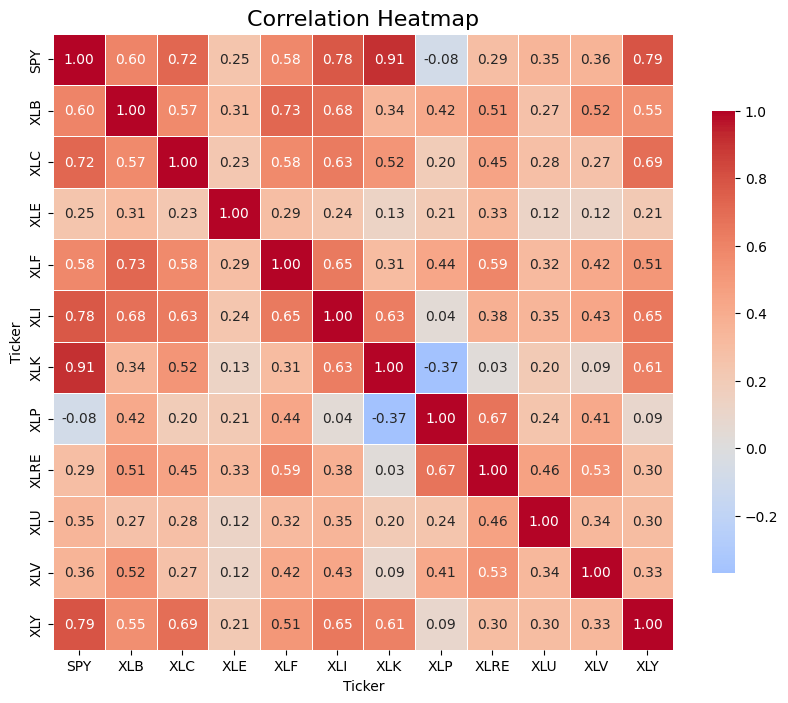

In [ ]:

# Example usage
tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","SPY"]
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# Short Term Sector Rotation Strategy

In [ ]:
class STSectorRotationRanker:
    def __init__(self, price_data: pd.DataFrame, sector_etfs: list, benchmark: str = 'SPY'):
        """
        price_data: DataFrame of adjusted closes with Date index (ascending) and columns for tickers (including benchmark).
        sector_etfs: list of sector ETF tickers to rank (strings).
        benchmark: ticker string present in price_data used as market benchmark (default 'SPY').

        """
        self.price_data = price_data.copy().sort_index()
        self.sector_etfs = sector_etfs
        self.benchmark = benchmark

        if benchmark not in self.price_data.columns:
            raise ValueError(f"Benchmark {benchmark} not found in price_data columns.")

    def _relative_series(self, ticker):
        """Return ratio series ticker / benchmark (RS series)."""
        return self.price_data[ticker] / self.price_data[self.benchmark]

    def compute_basic_rs(self, short_window=21, mid_window=63, long_window=126):
        """Compute RS1M, RS3M and RS6M as relative % change vs benchmark over short/mid windows."""
        results = []
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                results.append({'ticker': t, 'RS1M': np.nan, 'RS3M': np.nan,'RS6M':np.nan})
                continue
            rel = self._relative_series(t)
            #rs1m = (rel.iloc[-1] / rel.shift(short_window).iloc[-1] - 1) if len(rel) > short_window else np.nan
            #rs3m = (rel.iloc[-1] / rel.shift(mid_window).iloc[-1] - 1) if len(rel) > mid_window else np.nan
            rs1m = rel.pct_change(short_window).iloc[-1] if len(rel) > short_window else np.nan
            rs3m = rel.pct_change(mid_window).iloc[-1] if len(rel) > mid_window else np.nan
            rs6m = rel.pct_change(long_window).iloc[-1] if len(rel) > long_window else np.nan
            results.append({'ticker': t, 'RS1M': rs1m, 'RS3M': rs3m,"RS6M":rs6m})
        return pd.DataFrame(results).set_index('ticker')

    def compute_rs_slope(self, window=21):
        """Compute linear regression slope of RS series over `window` bars (last window)."""
        slopes = {}
        x = np.arange(window)
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                slopes[t] = np.nan
                continue
            rel = self._relative_series(t).dropna()
            if len(rel) < window:
                slopes[t] = np.nan
                continue
            y = rel.values[-window:]
            slope, intercept, r, p, se = linregress(x, y)
            slopes[t] = slope
        return pd.Series(slopes, name='RS_Slope')

    def compute_rolling_rs_acceleration(self, slope_window=21, accel_window=5):
        """
        Compute acceleration = change in rolling slope over accel_window steps.
        slope_window: how many bars to fit each rolling slope
        accel_window: how many slope-steps to look back for acceleration
        """
        acc = {}
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                acc[t] = np.nan
                continue
            rel = self._relative_series(t).dropna()
            if len(rel) < slope_window + accel_window:
                acc[t] = np.nan
                continue
            slopes = []
            for i in range(len(rel) - slope_window + 1):
                y = rel.values[i:i+slope_window]
                x = np.arange(slope_window)
                slope = linregress(x, y)[0]
                slopes.append(slope)
            slopes = np.array(slopes)
            acc_val = slopes[-1] - slopes[-1-accel_window] if len(slopes) > accel_window else np.nan
            acc[t] = acc_val
        return pd.Series(acc, name='RS_Acceleration')

    def merge_with_breadth(self):
      """
      Merge RS factors with breadth metrics
      """
      rs = self.compute_basic_rs()
      slope = self.compute_rs_slope()
      accel = self.compute_rolling_rs_acceleration()
      merged_df = rs.join(slope).join(accel)
      return merged_df

    def compute_leader_score(self, rs1w=0.5, rs3w=0.3, rs6w=0.2,slopew=0, accelw=0):
        """
        rs1w=0.4, rs3w=0.4, slopew=0.15, accelw=0.05
        Produce a DataFrame with RS1M, RS3M, RS6M, RS_Slope, RS_Acceleration and Leader_Score.
        Leader_Score computed as weighted z-scores of metrics.
        """
        rs = self.compute_basic_rs()
        slope = self.compute_rs_slope()
        accel = self.compute_rolling_rs_acceleration()

        df = rs.join(slope).join(accel)

        def zscore_col(s):
            # Use standard zscore; safe-guard against zero std
            return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)

        z_rs1   = zscore_col(df['RS1M'])
        z_rs3   = zscore_col(df['RS3M'])
        z_rs6   = zscore_col(df['RS6M'])
        z_slope = zscore_col(df['RS_Slope'])
        z_accel = zscore_col(df['RS_Acceleration'])

        score = rs1w*z_rs1 + rs3w*z_rs3 + rs6w*z_rs6 + slopew*z_slope + accelw*z_accel
        df['Leader_Score'] = score
        return df[['RS1M','RS3M', 'RS6M','RS_Slope','RS_Acceleration','Leader_Score']]

    def final_ranking(self):
      """
       Return final ranking DataFrame. If breadth_df provided it will be joined.
       Adds a new column 'Rank' where highest Leader_Score gets rank 1.
      """
      # Compute the leader score
      merged = self.compute_leader_score()
      # Sort by Leader_Score descending
      merged = merged.sort_values('Leader_Score', ascending=False)

      # Add a new ranking column
      merged['Rank'] = merged['Leader_Score'].rank(method='first', ascending=False).astype(int)


      return merged

In [ ]:
start_date = "2023-10-01"
end_date   = "2025-12-31"
week_end_date   = "2025-12-31"


tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","GBTC","GLD","MAGS","SPY"]
sectors = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","GBTC","GLD","MAGS"]

if __name__ == "__main__":



  data = yf.download( tickers, start=start_date, end=end_date, interval="1d",auto_adjust=True)['Close']
  price_data = data.ffill().dropna()
  # Instantiate and run ----------
  ranker = STSectorRotationRanker(price_data=price_data, sector_etfs=sectors, benchmark='SPY')
  df_ranking = ranker.final_ranking()

  #print(breadth_df)
def label_rs1m(rs1m):
    if rs1m >= 0.06:  return "BULLISH ≥6%"
    if rs1m >= 0.02:  return "Positive +2–6%"
    if rs1m >= -0.02: return "Neutral ±2%"
    if rs1m >= -0.05: return "BEARISH –2 to –5%"
    return "COLLAPSING <–5%"

def label_rs3m(rs3m):
    if rs3m >= 0.08:  return "LEADING ≥8%"
    if rs3m >= 0.00:  return "Recovering 0–8%"
    if rs3m >= -0.05: return "Lagging –5 to 0%"
    return "DEAD <–5%"

def label_rs_slope(slope):
    if slope >= 0.0045:      return "ROCKET / Parabolic"
    if slope >= 0.0030:      return "Very Strong Uptrend"
    if slope >= 0.0020:      return "Strong Uptrend"
    if slope >= 0.0012:      return "Moderate Uptrend"
    if slope >= 0.0006:      return "Mild Uptrend"
    if slope >= 0.0000:      return "Flat / Barely Positive"
    if slope >= -0.0010:     return "Flat / Losing Ground"
    return "Downtrend — Avoid"
def interpret_acceleration(acc):
      if acc >= 0.00030: return "ROCKET / Exploding"
      if acc >= 0.00020: return "Very strong acceleration"
      if acc >= 0.00012: return "Strong acceleration"
      if acc >= 0.00008: return "Positive acceleration"
      if acc >= 0.00000: return "Neutral/slightly positive"
      return "Deceleration / avoid"

def regime(row):
    if row['Slope_Label'].startswith('ROCKET') or row['Accel_Description'].startswith('ROCKET'):
        return "MONSTER INCOMING"
    if 'Strong' in row['Slope_Label'] or 'Very Strong' in row['Accel_Description']:
        return "Clear Leadership"
    if row['RS_Slope'] > 0.0015 and row['RS_Acceleration'] > 0.00015:
        return "Strong & Accelerating"
    if row['RS_Slope'] > 0:
        return "Improving"
    return "Wait / Avoid"



df_ranking['RS1M_Label'] = df_ranking['RS1M'].apply(label_rs1m)
df_ranking['RS3M_Label'] = df_ranking['RS3M'].apply(label_rs3m)
df_ranking['Slope_Label'] = df_ranking['RS_Slope'].apply(label_rs_slope)
df_ranking['Accel_Description'] = df_ranking['RS_Acceleration'].apply(interpret_acceleration)
df_ranking['Regime'] = df_ranking.apply(regime, axis=1)

def quick_verdict(row):
    bad_short = row['RS1M'] < -0.02                     # short-term momentum against us
    bad_long  = row['RS3M'] < -0.08                     # still in deep bear market
    monster   = (row['RS_Slope'] >= 0.0035) or (row['RS_Acceleration'] >= 0.00025)

    if bad_short and not monster:
        return "AVOID — short-term momentum too negative"
    if bad_long and row['Rank'] <= 2:
        return "CAUTION — still deeply underwater"
    if row['RS1M'] >= 0.04 and row['RS_Slope'] >= 0.002:
        return "SCREAMING BUY"
    return "Good"

df_ranking['Quick_Verdict'] = df_ranking.apply(quick_verdict, axis=1)


df_ranking

[*********************100%***********************]  14 of 14 completed


,RS1M,RS3M,RS6M,RS_Slope,RS_Acceleration,Leader_Score,Rank,RS1M_Label,RS3M_Label,Slope_Label,Accel_Description,Regime,Quick_Verdict
ticker,,,,,,,,,,,,,
GLD,0.074794,0.147881,0.095583,0.001646,0.000161,1.475020,1,BULLISH ≥6%,LEADING ≥8%,Moderate Uptrend,Strong acceleration,Strong & Accelerating,Good
XLV,0.101353,0.084717,0.028772,0.001289,0.000268,1.310498,2,BULLISH ≥6%,LEADING ≥8%,Moderate Uptrend,Very strong acceleration,Improving,Good
XLU,0.011770,0.018538,-0.038276,0.000059,0.000032,0.237518,3,Neutral ±2%,Recovering 0–8%,Flat / Barely Positive,Neutral/slightly positive,Improving,Good
XLE,0.033740,-0.050050,-0.032725,0.000130,-0.000093,0.174611,4,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Deceleration / avoid,Improving,Good
XLC,-0.001931,-0.021510,-0.018377,0.000099,0.000260,0.031852,5,Neutral ±2%,Lagging –5 to 0%,Flat / Barely Positive,Very strong acceleration,Improving,Good
XLK,-0.053381,0.027859,0.066066,-0.000670,-0.000234,-0.007003,6,COLLAPSING <–5%,Recovering 0–8%,Flat / Losing Ground,Deceleration / avoid,Wait / Avoid,AVOID — short-term momentum too negative
XLF,0.029798,-0.067158,-0.096548,0.000045,0.000001,-0.054808,7,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Neutral/slightly positive,Improving,Good
XLRE,0.031092,-0.065875,-0.129361,0.000068,0.000083,-0.111153,8,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Positive acceleration,Improving,Good
XLP,0.042499,-0.068796,-0.166976,0.000286,0.000215,-0.114755,9,Positive +2–6%,DEAD <–5%,Flat / Barely Positive,Very strong acceleration,Improving,Good


# Sector Rotation Engine (70/30 6M+12M RS vs SPY)

In [ ]:
class SectorRotationRanker:
    def __init__(self, price_data: pd.DataFrame, sector_etfs: list, benchmark: str = 'SPY'):
        """
        price_data: DataFrame of adjusted closes with Date index (ascending) and columns for tickers (including benchmark).
        sector_etfs: list of sector ETF tickers to rank (strings).
        benchmark: ticker string present in price_data used as market benchmark (default 'SPY').

        """
        self.price_data = price_data.copy().sort_index()
        self.sector_etfs = sector_etfs
        self.benchmark = benchmark

        if benchmark not in self.price_data.columns:
            raise ValueError(f"Benchmark {benchmark} not found in price_data columns.")

    def _relative_series(self, ticker):
        """Return ratio series ticker / benchmark (RS series)."""
        return self.price_data[ticker] / self.price_data[self.benchmark]

    def compute_basic_rs(self, short_window=126, mid_window=252):
        """Compute RS6M and RS12M as relative % change vs benchmark over short/mid windows."""
        results = []
        for t in self.sector_etfs:
            if t not in self.price_data.columns:
                results.append({'ticker': t, 'RS6M': np.nan, 'RS12M': np.nan})
                continue
            rel = self._relative_series(t)
            rs6m = rel.pct_change(short_window).iloc[-1] if len(rel) > short_window else np.nan
            rs12m = rel.pct_change(mid_window).iloc[-1] if len(rel) > mid_window else np.nan
            results.append({'ticker': t, 'RS6M': rs6m, 'RS12M': rs12m})
        return pd.DataFrame(results).set_index('ticker')

    def compute_leader_score(self, rs6w=0.7, rs12w=0.3):
        """
        rs6w=0.4, rs12w=0.4
        Produce a DataFrame with RS1M, RS3M,and Leader_Score.
        Leader_Score computed as weighted z-scores of metrics.
        """
        rs = self.compute_basic_rs()
        df = rs.copy()

        def zscore_col(s):
            # Use standard zscore; safe-guard against zero std
            return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)

        z_rs6   = zscore_col(df['RS6M'])
        z_rs12   = zscore_col(df['RS12M'])

        score = rs6w*z_rs6 + rs12w*z_rs12
        df['Score'] = score
        return df[['RS6M','RS12M','Score']]

    def final_ranking(self):
      """
       Return final ranking DataFrame. If breadth_df provided it will be joined.
       Adds a new column 'Rank' where highest Leader_Score gets rank 1.
      """
      # Compute the leader score
      merged = self.compute_leader_score()


      # Only select ETFs that have excellent marked breadth
      # Sort by Leader_Score descending
      merged = merged.sort_values('Score', ascending=False)

      # Add a new ranking column
      merged['Rank'] = merged['Score'].rank(method='first', ascending=False).astype(int)


      return merged

def quick_verdict(row):
    """
    One-line verdict when your ranking is based on 70/30 RELATIVE STRENGTH vs SPY.
    Row must contain: 'RS_6M', 'RS_12M', 'Score', 'Rank'
    """
    rs6   = row['RS6M']      # e.g. +0.184 = +18.4% outperformance vs SPY in 6 months
    rs12  = row['RS12M']
    score = row['Score']
    rank  = row['Rank']

    # ── TOP-2 → ALWAYS obey the model ─────────────────────────────────
    if rank == 1:
        if rs6 >= 0.20:   return "MONSTER #1 – strongest leader in years"
        if rs6 >= 0.12:   return "STRONG #1 – ride it hard"
        return "Weak #1 but still the leader – hold"

    if rank == 2:
        if rs6 >= 0.15:   return "VERY STRONG #2 – excellent companion"
        if rs6 >= 0.08:   return "SOLID #2 – normal winner"
        return "Marginal #2 – still hold mechanically"

    # ── Ranks 3–5 → only interesting if extremely close ───────────────
    if 3 <= rank <= 5:
        top2_score = df[df['Rank'].isin([1,2])]['Score'].min()
        if score >= top2_score * 0.96:   # within 4% of the weaker Top-2
            return "Almost made it – watch for next month"
        else:
            return "Mid-pack – ignore"

    # ── Bottom half → only flag disasters or hidden gems ───────────────
    if rs6 <= -0.20:
        return "CRASHING vs SPY – toxic"
    if rs12 <= -0.30:
        return "DEEP BEAR phase – dead for years"
    if rs6 >= 0.20 and rs12 >= 0.20:
        return "Strong but not ranked yet – model waiting for confirmation"

    return "Neutral – ignore"

In [ ]:

if __name__ == "__main__":
  #tickers = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC","SPY"]
  data = yf.download( tickers, start=start_date, end=end_date,interval="1d",auto_adjust=True)['Close']
  #price_data = data.ffill().dropna()
  price_data = data
  # Instantiate and run ----------
  #sectors = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB","XLC"]
  ranker = SectorRotationRanker(price_data=price_data, sector_etfs=sectors, benchmark='SPY')
  df = ranker.final_ranking()
  df.reset_index(inplace=True)
  df['Quick_Verdict'] = df.apply(quick_verdict, axis=1)

# Show only what matters
df.sort_values('Rank')[['ticker','RS6M','RS12M','Score','Rank','Quick_Verdict']]



[*********************100%***********************]  14 of 14 completed


,ticker,RS6M,RS12M,Score,Rank,Quick_Verdict
0,GLD,0.095583,0.381861,2.056101,1,Weak #1 but still the leader – hold
1,XLK,0.066066,0.065218,1.181463,2,Marginal #2 – still hold mechanically
2,XLV,0.028772,-0.046565,0.669397,3,Mid-pack – ignore
3,XLC,-0.018377,0.035422,0.481361,4,Mid-pack – ignore
4,XLU,-0.038276,-0.012361,0.232532,5,Mid-pack – ignore
5,XLY,-0.047889,-0.064959,0.051618,6,Neutral – ignore
6,XLE,-0.032725,-0.153275,-0.015335,7,Neutral – ignore
7,XLI,-0.070570,-0.060844,-0.111498,8,Neutral – ignore
8,XLF,-0.096548,-0.084476,-0.356635,9,Neutral – ignore
9,XLB,-0.103319,-0.171352,-0.586561,10,Neutral – ignore


Here is the clean, professional way to handle AVWAP entry for a monthly rotation model.
This is the same structure used by institutional traders (anchored VWAP for timing + momentum for direction).

I’ll give you a simple, robust, and consistent rule set that will prevent bad entries while keeping you aligned with your momentum model.

✅ Step 1 — Pick Your Anchor for AVWAP

For monthly rotation, you should anchor AVWAP to:

🔹 The first trading day of the month (MTD AVWAP)

This tells you immediately whether buyers are in control for the new cycle.

Alternatively, you can use:

🔹 The last swing low AVWAP

This is used by advanced traders but requires pattern detection.

For simplicity and reliability, we will use:

⭐ MTD AVWAP (anchored to day 1 of each month)
✅ Step 2 — Entry Rules (Institutional-Style AVWAP Filter)

You evaluate these rules on the 2nd trading day of the month, just like you planned.

A sector ETF gets a “✓ BUY” only if ALL are true:

✔ Rule 1 — Price > MTD AVWAP

This ensures buyers have regained control.

Why it matters:
If price is below AVWAP → sellers still dominate → avoid.

✔ Rule 2 — AVWAP is sloping upward

Slope = AVWAP(today) > AVWAP(yesterday)

This prevents you from entering when AVWAP is falling (distribution).

✔ Rule 3 — Price has made a higher low above AVWAP

This can be simple:

The low of today or yesterday is above AVWAP
OR

Today’s low > Yesterday’s low (both above AVWAP)

This confirms demand stepping in.

✔ Rule 4 — Price closes strong (optional but recommended)

Close > 5-day moving average (5SMA)

This is a “final confirmation” that buyers pushed price into strength.

📌 Final Entry Decision
If an ETF ranks top 2 by momentum (6M/12M RS)

AND
passes all AVWAP rules above
→ BUY on 2nd trading day.

If it fails AVWAP filter

→ Skip it and hold SPY or the next ETF that qualifies.

This prevents buying into weakness.

🎯 Why This Works Perfectly With Monthly Rotation

Because long-term momentum (6M/12M) can identify the leaders…

…but AVWAP prevents:

early entries

buying at the top

entering during a pullback

entering before a confirmed bid

fake momentum

Your strategy becomes:

**Momentum selects the asset.

AVWAP confirms the trade is safe.**

# Absolute Momentum Variant

In [ ]:
def quick_verdicts(row, df=None):
    """
    One-line verdict for absolute momentum strategy (1M/3M/6M average).
    Row must contain: '1M_ret', '3M_ret', '6M_ret', 'Score', 'Rank'
    df is optional – provide it for "close contender" detection on ranks 3–5.
    """
    ret1  = row['Ret1M']    # e.g. +0.148 = +14.8% in past month
    ret3  = row['Ret3M']
    ret6  = row['Ret6M']
    score = row['Score']     # composite average
    rank  = row['Rank']

    # ── TOP-2 → ALWAYS obey the model ─────────────────────────────────
    if rank == 1:
        if ret1 >= 0.15:   return "MONSTER #1 – exploding short-term"
        if ret3 >= 0.20:   return "STRONG #1 – dominant medium-term leader"
        if score >= 0.15:  return "STRONG #1 – ride it hard"
        if score >= 0.10:  return "SOLID #1 – good momentum"
        return "Weak #1 but still the leader – hold mechanically"

    if rank == 2:
        if ret1 >= 0.12:   return "VERY STRONG #2 – hot short-term companion"
        if ret3 >= 0.15:   return "STRONG #2 – solid medium-term"
        if score >= 0.12:  return "SOLID #2 – reliable pair"
        return "Marginal #2 – still hold per rules"

    # ── Ranks 3–5 → flag if very close to Top-2 ───────────────────────
    if 3 <= rank <= 5 and df is not None:
        top2_min_score = df[df['Rank'].isin([1,2])]['Score'].min()
        if top2_min_score > 0:
            gap = (top2_min_score - score) / top2_min_score
            if gap <= 0.05:   # within ~5%
                return f"Very close #{rank} (only {gap:.1%} behind) – potential next month"
            if gap <= 0.10:
                return "Close contender – watch"
        return "Mid-pack – ignore"

    # ── Lower ranks → flag standouts or disasters ─────────────────────
    if rank > 5:
        if ret1 <= -0.10:
            return "Short-term CRASHING – avoid"
        if ret6 <= -0.20:
            return "Long-term BEAR – deep drawdown"
        if score >= 0.12 and rank <= 6:
            return "Strong momentum but missed cut – model needs consistency"
        if ret1 >= 0.15:
            return "Short-term rocket but lacking broader confirmation"

    return "Neutral – no strong signal"

In [ ]:


class AbsoluteMomentum_SectorRotationRanker:
    def __init__(self, price_data: pd.DataFrame, sector_etfs: list):
        """
        price_data: DataFrame with Date index (ascending) and adjusted close columns.
                    Must contain at least the sector ETFs (SPY optional, not used here).
        sector_etfs: list of the 11 sector tickers, e.g. ['XLK','XLF',...]
        """
        self.price_data = price_data.copy().sort_index()
        self.sector_etfs = sector_etfs

    def compute_absolute_momentum(self, short_window=21, mid_window=63, long_window=126):
        """
        Returns simple total returns (not pct_change from yesterday) over 1M/3M/6M.
        """
        results = []
        prices = self.price_data[self.sector_etfs]

        for ticker in self.sector_etfs:
            ser = prices[ticker].dropna()
            if len(ser) < long_window:
                results.append({'ticker': ticker, 'Ret1M': np.nan, 'Ret3M': np.nan, 'Ret6M': np.nan})
                continue

            ret1m = ser.iloc[-1] / ser.iloc[-1-short_window] - 1
            ret3m = ser.iloc[-1] / ser.iloc[-1-mid_window]   - 1
            ret6m = ser.iloc[-1] / ser.iloc[-1-long_window]  - 1

            results.append({'ticker': ticker, 'Ret1M': ret1m, 'Ret3M': ret3m, 'Ret6M': ret6m})

        return pd.DataFrame(results).set_index('ticker')

    def compute_leader_score(self, w1=0.7, w3=0.3, w6=0):
        """
        Weighted composite score with short-term bias by default (50/30/20).
        You can use equal weights with w1=w3=w6=1/3 if you prefer.
        """
        mom = self.compute_absolute_momentum()

        # Simple weighted average — no z-scores needed for absolute momentum
        mom['Score'] = (w1 * mom['Ret1M'] + w3 * mom['Ret3M'] + w6 * mom['Ret6M'])

        return mom[['Ret1M', 'Ret3M', 'Ret6M', 'Score']]


    def final_ranking(self, w1=0.7, w3=0.3, w6=0., ascending=False):
        """
        Returns fully ranked table + quick verdict column.
        Default = short-term bias (50/30/20).
        """
        df = self.compute_leader_score(w1=w1, w3=w3, w6=w6)
        df = df.sort_values('Score', ascending=ascending)

        df['Rank'] = np.arange(1, len(df) + 1)

        # Optional pretty verdict (using the function we built earlier)
        df['Verdict'] = df.apply(lambda row: quick_verdicts(row, df=df), axis=1)

        return df.round(4)

    def get_top2(self, **kwargs):
        """Convenience: returns the two tickers you should hold next month"""
        ranking = self.final_ranking(**kwargs)
        return ranking.index[:12].tolist()

In [ ]:
# Assuming you already have price_data loaded with all 11 sectors up to 2025-11-29
tickers = tickers[:-1]
price_data = yf.download( tickers, start=start_date, end=week_end_date, interval="1d",auto_adjust=True)['Close']
price_data = data.ffill().dropna()

ranker = AbsoluteMomentum_SectorRotationRanker(price_data, tickers)

# 50/30/20 short-term bias (recommended right now)
ranking = ranker.final_ranking(w1=0.5, w3=0.3, w6=0.2)
ranking.head()
#print(ranking.head(5))
#print("\n→ Buy equal-weight:", ranker.get_top2(w1=0.5, w3=0.3, w6=0.2))

[*********************100%***********************]  13 of 13 completed


,Ret1M,Ret3M,Ret6M,Score,Rank,Verdict
ticker,,,,,,
GLD,0.0685,0.2195,0.2776,0.1556,1,STRONG #1 – dominant medium-term leader
XLV,0.0949,0.1524,0.1997,0.1331,2,STRONG #2 – solid medium-term
XLU,0.0059,0.0821,0.1215,0.0519,3,Mid-pack – ignore
XLK,-0.0589,0.0920,0.2432,0.0468,4,Mid-pack – ignore
XLE,0.0277,0.0092,0.1280,0.0422,5,Mid-pack – ignore
